# 🧪 Knowledge Distillation

**Knowledge Distillation (KD)** is a technique to transfer the "knowledge" from a large, accurate **Teacher** model to a smaller, faster **Student** model.

### The Intuition: "Dark Knowledge"

A large, trained Teacher model produces **soft predictions** (probability distributions) that contain rich information, often called **"dark knowledge."**

Example: If an image is a "Truck," the Teacher might output:
* **Truck:** 0.85 (Hard Label)
* **Car:** 0.14 (Soft Knowledge: It shares visual features like tires and shape with a car.)
* **Bird:** 0.01

KD forces the Student to match these soft, informative targets, not just the hard, one-hot labels.

### The Objective Function

The Student minimizes a combined loss function:

$$L_{total} = \alpha \cdot L_{KD} + (1 - \alpha) \cdot L_{CE}$$

* $L_{KD}$ (Distillation Loss): **Kullback-Leibler (KL) Divergence** between the Student's soft predictions and the Teacher's soft predictions.
* $L_{CE}$ (Student Loss): Standard **Cross-Entropy** loss with the true hard labels.
* **Temperature ($T$):** The logits are softened by dividing them by $T > 1$ before calculating $L_{KD}$. This exposes more details in the probability distribution.

## 1. Setup and Hyperparameters

We set up the parameters, including the crucial distillation hyperparameters: **Temperature ($T$)** and **Alpha ($\alpha$)**.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time

# Configuration
BATCH_SIZE = 128
LEARNING_RATE = 0.01
EPOCHS = 10
TEMP = 7             # Temperature for distillation (T > 1)
ALPHA = 0.3          # Weight for Distillation Loss (0 < alpha < 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Data Loading (CIFAR-10) ---
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


## 2. Define Models: Teacher and Student

The **Teacher** is a large, pre-trained ResNet-18. The **Student** is a much smaller custom CNN.

In [3]:
# --- 1. The Teacher (ResNet-18) ---
def get_teacher_model():
    # Load ResNet18 with pre-trained weights
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Modify the classification head for 10 classes (CIFAR-10)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

# --- 2. The Student (Small Custom CNN) ---
class StudentCNN(nn.Module):
    def __init__(self):
        super(StudentCNN, self).__init__()
        # A simple, shallow network for comparison
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64) # 32x32 -> 16x16 -> 8x8
        self.fc2 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate
teacher_model = get_teacher_model().to(device)
student_model = StudentCNN().to(device)

# --- Parameter Count Comparison ---
t_params = sum(p.numel() for p in teacher_model.parameters())
s_params = sum(p.numel() for p in student_model.parameters())

print(f"Teacher Parameters: {t_params:,}")
print(f"Student Parameters: {s_params:,}")
print(f"Ratio: Teacher is {t_params/s_params:.1f}x larger than Student")

Teacher Parameters: 11,181,642
Student Parameters: 136,874
Ratio: Teacher is 81.7x larger than Student


## 3. Preparation: Training the Teacher

We quickly train the Teacher (ResNet-18) to ensure it achieves high performance on CIFAR-10 before distillation.

In [5]:
def train_standard(model, loader, optimizer, criterion, epochs, name="Model"):
    model.train()
    for epoch in range(epochs):
        correct = 0
        total = 0
        running_loss = 0.0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()

        print(f"{name} Epoch {epoch+1}/{epochs} | Acc: {100 * correct / total:.2f}% | Loss: {running_loss/len(loader):.4f}")

# --- Train Teacher ---
print("Training Teacher (ResNet-18) for 10 epochs...")
criterion = nn.CrossEntropyLoss()
optimizer_teacher = optim.SGD(teacher_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

train_standard(teacher_model, train_loader, optimizer_teacher, criterion, epochs=10, name="Teacher")

# Set teacher to evaluation mode and freeze weights for distillation
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False
print("Teacher is now ready for distillation.")

Training Teacher (ResNet-18) for 10 epochs...
Teacher Epoch 1/10 | Acc: 71.16% | Loss: 0.8473
Teacher Epoch 2/10 | Acc: 76.28% | Loss: 0.6933
Teacher Epoch 3/10 | Acc: 79.51% | Loss: 0.6048
Teacher Epoch 4/10 | Acc: 80.84% | Loss: 0.5549
Teacher Epoch 5/10 | Acc: 82.19% | Loss: 0.5174
Teacher Epoch 6/10 | Acc: 83.02% | Loss: 0.4928
Teacher Epoch 7/10 | Acc: 83.57% | Loss: 0.4707
Teacher Epoch 8/10 | Acc: 84.26% | Loss: 0.4500
Teacher Epoch 9/10 | Acc: 85.21% | Loss: 0.4264
Teacher Epoch 10/10 | Acc: 85.59% | Loss: 0.4139
Teacher is now ready for distillation.


## 4. The Distillation Loss Implementation

We implement the combined loss function: $L_{total} = \alpha L_{KD} + (1 - \alpha) L_{CE}$.

In [6]:
def distillation_loss(student_logits, teacher_logits, labels, T, alpha):
    """
    Calculates the combined KD loss.
    """
    # 1. Hard Label Loss (Standard Cross Entropy)
    hard_loss = F.cross_entropy(student_logits, labels)

    # 2. Distillation Loss (Soft Targets)
    # Target (Teacher) softening: Softmax(logits / T)
    soft_targets = F.softmax(teacher_logits / T, dim=1)

    # Input (Student) softening: LogSoftmax(logits / T)
    soft_prob = F.log_softmax(student_logits / T, dim=1)

    # KL Divergence Loss
    # We use reduction='batchmean' (default in PyTorch >= 1.10 for KLDivLoss)
    # And multiply by T^2 to ensure gradients are correctly scaled relative to hard_loss
    distillation_loss_val = F.kl_div(soft_prob, soft_targets.detach(), reduction='batchmean') * (T**2)

    # Combined Loss
    loss = alpha * distillation_loss_val + (1 - alpha) * hard_loss

    return loss

## 5. Training Loop: Knowledge Distillation

The Student is trained to match the Teacher's soft predictions and the true hard labels simultaneously.

In [12]:
# Create a fresh student model for distillation
student_distilled = StudentCNN().to(device)
optimizer_distill = optim.SGD(student_distilled.parameters(), lr=LEARNING_RATE, momentum=0.9)

print(f"Starting Distillation Training (T={TEMP}, Alpha={ALPHA}) for {EPOCHS} epochs...")

distilled_train_losses = []
distilled_train_accuracies = []

for epoch in range(EPOCHS):
    student_distilled.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Get Teacher outputs (must be detached from graph)
        with torch.no_grad():
            teacher_logits = teacher_model(inputs)

        # 2. Get Student outputs
        optimizer_distill.zero_grad()
        student_logits = student_distilled(inputs)

        # 3. Calculate Combined Distillation Loss
        loss = distillation_loss(student_logits, teacher_logits, labels, TEMP, ALPHA)

        loss.backward()
        optimizer_distill.step()

        running_loss += loss.item()
        _, predicted = torch.max(student_logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)
    distilled_train_accuracies.append(epoch_acc)
    distilled_train_losses.append(epoch_loss)

    print(f"Distill Epoch {epoch+1}/{EPOCHS} | Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f}")

Starting Distillation Training (T=7, Alpha=0.3) for 10 epochs...
Distill Epoch 1/10 | Acc: 37.57% | Loss: 2.7682
Distill Epoch 2/10 | Acc: 51.48% | Loss: 2.0332
Distill Epoch 3/10 | Acc: 57.18% | Loss: 1.7494
Distill Epoch 4/10 | Acc: 60.29% | Loss: 1.5955
Distill Epoch 5/10 | Acc: 62.94% | Loss: 1.4714
Distill Epoch 6/10 | Acc: 65.01% | Loss: 1.3776
Distill Epoch 7/10 | Acc: 66.12% | Loss: 1.3213
Distill Epoch 8/10 | Acc: 67.41% | Loss: 1.2738
Distill Epoch 9/10 | Acc: 68.22% | Loss: 1.2348
Distill Epoch 10/10 | Acc: 69.12% | Loss: 1.2046


## 6. Baseline Comparison

We train an identical Student model from scratch using only standard Cross-Entropy loss to establish a **Baseline**.

In [13]:
# Create another fresh student model (Baseline)
student_scratch = StudentCNN().to(device)
optimizer_scratch = optim.SGD(student_scratch.parameters(), lr=LEARNING_RATE, momentum=0.9)

print("\nStarting Baseline Training (Student from Scratch)...")

baseline_train_losses = []
baseline_train_accuracies = []

def train_standard_with_history(model, loader, optimizer, criterion, epochs, name="Model", losses_list=None, accuracies_list=None):
    model.train()
    for epoch in range(epochs):
        correct = 0
        total = 0
        running_loss = 0.0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()

        epoch_acc = 100 * correct / total
        epoch_loss = running_loss / len(loader)

        if losses_list is not None:
            losses_list.append(epoch_loss)
        if accuracies_list is not None:
            accuracies_list.append(epoch_acc)

        print(f"{name} Epoch {epoch+1}/{epochs} | Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f}")

# Reuse the standard training function
train_standard_with_history(student_scratch, train_loader, optimizer_scratch, criterion, epochs=EPOCHS, name="Baseline", losses_list=baseline_train_losses, accuracies_list=baseline_train_accuracies)


Starting Baseline Training (Student from Scratch)...
Baseline Epoch 1/10 | Acc: 35.67% | Loss: 1.7700
Baseline Epoch 2/10 | Acc: 48.56% | Loss: 1.4225
Baseline Epoch 3/10 | Acc: 54.60% | Loss: 1.2665
Baseline Epoch 4/10 | Acc: 58.54% | Loss: 1.1669
Baseline Epoch 5/10 | Acc: 61.27% | Loss: 1.0845
Baseline Epoch 6/10 | Acc: 62.69% | Loss: 1.0438
Baseline Epoch 7/10 | Acc: 64.79% | Loss: 0.9972
Baseline Epoch 8/10 | Acc: 65.87% | Loss: 0.9662
Baseline Epoch 9/10 | Acc: 67.09% | Loss: 0.9376
Baseline Epoch 10/10 | Acc: 67.66% | Loss: 0.9157


## 7. Final Evaluation

Compare the final test accuracy of all three models.

In [14]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

acc_teacher = evaluate_model(teacher_model, test_loader)
acc_distilled = evaluate_model(student_distilled, test_loader)
acc_scratch = evaluate_model(student_scratch, test_loader)

print("--- Final Test Accuracy Comparison ---")
print(f"Teacher (ResNet-18):      {acc_teacher:.2f}%")
print(f"Student (Distilled):      {acc_distilled:.2f}%")
print(f"Student (From Scratch):   {acc_scratch:.2f}%")

print(f"\nImprovement due to KD: +{acc_distilled - acc_scratch:.2f}%")

--- Final Test Accuracy Comparison ---
Teacher (ResNet-18):      82.83%
Student (Distilled):      72.16%
Student (From Scratch):   70.45%

Improvement due to KD: +1.71%


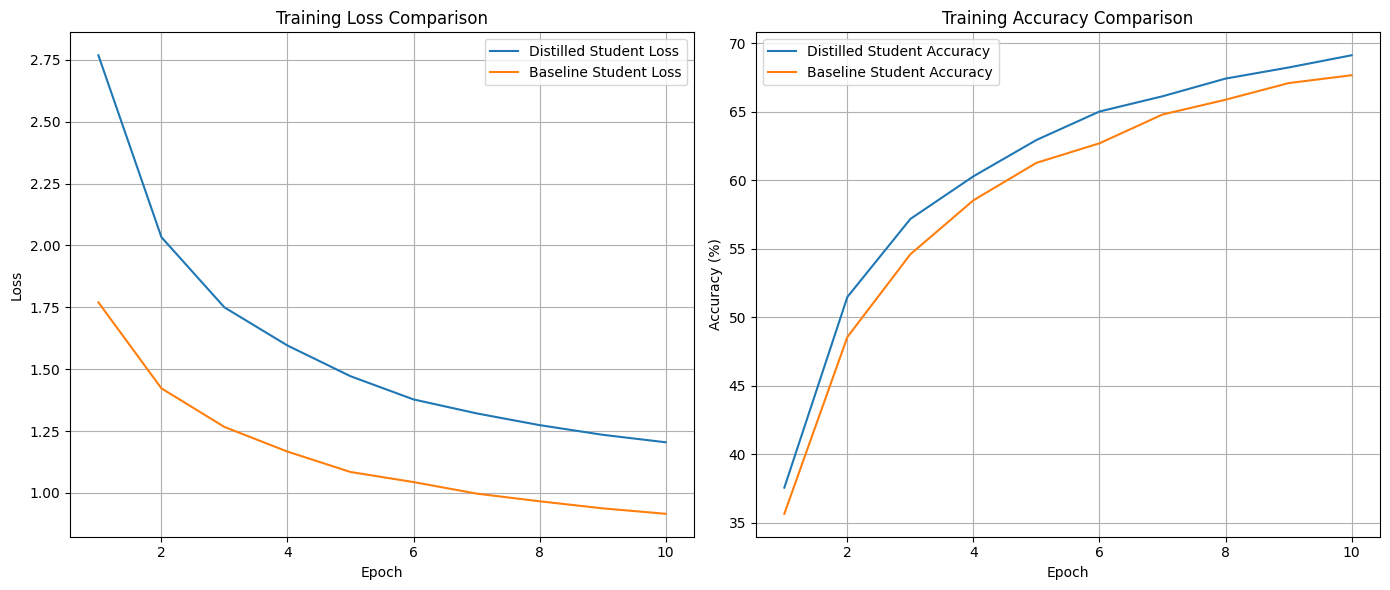

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 6))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, distilled_train_losses, label='Distilled Student Loss')
plt.plot(epochs_range, baseline_train_losses, label='Baseline Student Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, distilled_train_accuracies, label='Distilled Student Accuracy')
plt.plot(epochs_range, baseline_train_accuracies, label='Baseline Student Accuracy')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Conclusion

The results demonstrate that the **Distilled Student** achieved a higher accuracy than the **Baseline Student** (trained from scratch), proving the efficacy of transferring **"dark knowledge"** from the large Teacher model.

**Knowledge Distillation** is a powerful method for model compression and acceleration without sacrificing too much performance.